# CrediFlux — Simple Linear Regression Baseline

This notebook is part of the **CrediFlux** credit risk assessment and loan default prediction project. 

The objective of this notebook is to build a **simple baseline Linear Regression model** using the representative 50K subset (`crediflux_50k.csv`) to establish a performance baseline for future classification models.

## Notebook Structure
1. **Load 50K Dataset**
2. **Inspect Dataset**
3. **Define Binary Target**
4. **Select Numerical Features**
5. **Handle Missing Values**
6. **Train-Test Split**
7. **Feature Scaling**
8. **Linear Regression Training**
9. **Regression Metrics**
10. **Threshold Predictions**
11. **Classification Metrics**
12. **Visualizations**
13. **Baseline Interpretation**

---

## Environment Setup
First, we load the required python packages and configure visualizations.

In [1]:
# Environment Setup
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

# Configure visualizations
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.figsize"] = (12, 5)
plt.rcParams["font.size"] = 10

## 1. Load the 50K Dataset
We load `crediflux_50k.csv` and display shape, column names, data types, and check its content. 
Note: We do not use the full 10M row dataset to keep our baseline lightweight and interpretable.

In [2]:
# Resolve path to the 50K dataset (checking both local folder and parent folder for convenience)
data_paths = ['../data/crediflux_50k.csv', 'data/crediflux_50k.csv']
data_path = None
for path in data_paths:
    if os.path.exists(path):
        data_path = path
        break

if data_path is None:
    raise FileNotFoundError("Could not find crediflux_50k.csv in either '../data/' or 'data/' directory.")

print(f"Loading dataset from: {data_path}")
df = pd.read_csv(data_path)

# Display metadata
print(f"Dataset Shape: {df.shape}")
print(f"Number of columns: {len(df.columns)}")

Loading dataset from: ../data/crediflux_50k.csv


Dataset Shape: (50000, 151)
Number of columns: 151


C:\Users\Hashwin.M\AppData\Local\Temp\ipykernel_15720\2222450068.py:13: DtypeWarning: Columns (0,19,59,118) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(data_path)


### Display Columns and Data Types

In [3]:
print("Column Names:")
print(df.columns.tolist())
print("\nData Types:")
print(df.dtypes)

Column Names:
['id', 'member_id', 'loan_amnt', 'funded_amnt', 'funded_amnt_inv', 'term', 'int_rate', 'installment', 'grade', 'sub_grade', 'emp_title', 'emp_length', 'home_ownership', 'annual_inc', 'verification_status', 'issue_d', 'loan_status', 'pymnt_plan', 'url', 'desc', 'purpose', 'title', 'zip_code', 'addr_state', 'dti', 'delinq_2yrs', 'earliest_cr_line', 'fico_range_low', 'fico_range_high', 'inq_last_6mths', 'mths_since_last_delinq', 'mths_since_last_record', 'open_acc', 'pub_rec', 'revol_bal', 'revol_util', 'total_acc', 'initial_list_status', 'out_prncp', 'out_prncp_inv', 'total_pymnt', 'total_pymnt_inv', 'total_rec_prncp', 'total_rec_int', 'total_rec_late_fee', 'recoveries', 'collection_recovery_fee', 'last_pymnt_d', 'last_pymnt_amnt', 'next_pymnt_d', 'last_credit_pull_d', 'last_fico_range_high', 'last_fico_range_low', 'collections_12_mths_ex_med', 'mths_since_last_major_derog', 'policy_code', 'application_type', 'annual_inc_joint', 'dti_joint', 'verification_status_joint', 'ac

### Display First 5 Rows

In [4]:
df.head()

,id,member_id,loan_amnt,funded_amnt,funded_amnt_inv,term,int_rate,installment,grade,sub_grade,...,hardship_payoff_balance_amount,hardship_last_payment_amount,disbursement_method,debt_settlement_flag,debt_settlement_flag_date,settlement_status,settlement_date,settlement_amount,settlement_percentage,settlement_term
0,68387003,NaN,10000.0,10000.0,10000.0,36 months,12.88,336.37,C,C2,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN
1,68565380,NaN,14550.0,14550.0,14550.0,60 months,15.77,352.06,D,D1,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN
2,68537513,NaN,2000.0,2000.0,2000.0,36 months,8.49,63.13,B,B1,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN
3,68496845,NaN,24000.0,24000.0,24000.0,36 months,7.91,751.08,A,A5,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN
4,68340647,NaN,10000.0,10000.0,10000.0,36 months,11.99,332.10,C,C1,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN


### Display Basic Statistics

In [5]:
df.describe()

,member_id,loan_amnt,funded_amnt,funded_amnt_inv,int_rate,installment,annual_inc,dti,delinq_2yrs,fico_range_low,...,deferral_term,hardship_amount,hardship_length,hardship_dpd,orig_projected_additional_accrued_interest,hardship_payoff_balance_amount,hardship_last_payment_amount,settlement_amount,settlement_percentage,settlement_term
count,0.0,49999.000000,49999.000000,49999.000000,49999.000000,49999.000000,4.999900e+04,49966.000000,49999.000000,49999.000000,...,218.0,218.000000,218.0,218.000000,182.00000,218.000000,218.000000,772.000000,772.000000,772.000000
mean,NaN,14969.479890,14964.659793,14946.950981,13.090012,444.106623,7.779753e+04,18.767317,0.311806,698.438469,...,3.0,149.194495,3.0,13.610092,430.34044,11303.797798,196.048211,4998.730272,47.900337,13.593264
std,NaN,9192.263959,9190.551658,9194.545911,4.831713,267.470492,7.476197e+04,12.132108,0.860214,33.058038,...,0.0,122.799433,0.0,9.899927,344.46995,7739.198582,201.038092,3845.266450,6.993205,7.780741
min,NaN,500.000000,500.000000,0.000000,5.310000,15.760000,0.000000e+00,0.000000,0.000000,635.000000,...,3.0,7.320000,3.0,0.000000,21.96000,794.960000,0.020000,239.000000,20.000000,0.000000
25%,NaN,8000.000000,8000.000000,8000.000000,9.490000,250.100000,4.600000e+04,11.910000,0.000000,675.000000,...,3.0,55.072500,3.0,3.000000,160.91250,5346.587500,49.115000,2136.000000,45.000000,8.000000
50%,NaN,12700.000000,12675.000000,12625.000000,12.620000,377.090000,6.500000e+04,17.830000,0.000000,690.000000,...,3.0,114.765000,3.0,15.000000,343.24500,9214.355000,141.075000,4161.385000,45.000000,15.000000
75%,NaN,20000.000000,20000.000000,20000.000000,15.990000,591.425000,9.250000e+04,24.490000,0.000000,715.000000,...,3.0,195.157500,3.0,22.000000,568.53000,15324.030000,275.250000,6769.387500,50.000000,18.000000
max,NaN,40000.000000,40000.000000,40000.000000,30.990000,1714.540000,7.582566e+06,831.970000,21.000000,845.000000,...,3.0,642.950000,3.0,29.000000,1622.10000,35394.540000,1039.750000,28503.000000,100.000000,50.000000


## 2. Define the Target
We inspect the values of `loan_status` in the dataset. To construct a binary target for credit risk mapping, we only use clearly resolved cases:
- `Fully Paid` -> `0` (Non-default)
- `Charged Off` -> `1` (Default)

All unresolved or ongoing statuses (such as `Current`, `Late`, etc.) will be excluded from this experiment since the final credit default outcome is not yet resolved.

### Crucial Data Leakage Prevention
We create a target column `target`. Under no circumstances will `loan_status` itself be used as an input feature to the model, as it represents post-loan outcomes and would cause direct data leakage.

In [6]:
# Inspect unique loan statuses
print("Loan Status value counts:")
print(df['loan_status'].value_counts(dropna=False))

Loan Status value counts:
loan_status
Fully Paid                                             23814
Current                                                19426
Charged Off                                             5940
Late (31-120 days)                                       475
In Grace Period                                          186
Late (16-30 days)                                         96
Does not meet the credit policy. Status:Fully Paid        44
Does not meet the credit policy. Status:Charged Off       17
Default                                                    1
NaN                                                        1
Name: count, dtype: int64


In [7]:
# Filter the dataset to include only resolved outcomes
resolved_df = df[df['loan_status'].isin(['Fully Paid', 'Charged Off'])].copy()

# Map to binary targets
resolved_df['target'] = resolved_df['loan_status'].map({'Fully Paid': 0, 'Charged Off': 1})

print(f"Original dataset size: {df.shape[0]} rows")
print(f"Resolved dataset size: {resolved_df.shape[0]} rows")
print("\nTarget counts:")
print(resolved_df['target'].value_counts())
print("\nTarget distribution (%):")
print(resolved_df['target'].value_counts(normalize=True) * 100)

Original dataset size: 50000 rows
Resolved dataset size: 29754 rows

Target counts:
target
0    23814
1     5940
Name: count, dtype: int64

Target distribution (%):
target
0    80.036298
1    19.963702
Name: proportion, dtype: float64


## 3. Select a Small Set of Numerical Features
We automatically check for the existence of the following 12 key numerical features that could reasonably be available at the time of lending:
- `loan_amnt`, `annual_inc`, `int_rate`, `installment`, `dti`, `fico_range_low`, `fico_range_high`, `revol_bal`, `revol_util`, `open_acc`, `total_acc`, `delinq_2yrs`

In [8]:
candidate_features = [
    'loan_amnt', 'annual_inc', 'int_rate', 'installment', 'dti',
    'fico_range_low', 'fico_range_high', 'revol_bal', 'revol_util',
    'open_acc', 'total_acc', 'delinq_2yrs'
]

# Filter to find which candidates exist in resolved_df
features = [col for col in candidate_features if col in resolved_df.columns]
print(f"Available numerical features: {features}")

# Subset the dataframe
df_ml = resolved_df[['target'] + features].copy()

# Display missing value counts
print("\nMissing values per column:")
print(df_ml.isnull().sum())

# Display usable records
complete_records = df_ml.dropna().shape[0]
print(f"\nNumber of usable records (complete cases): {complete_records} out of {df_ml.shape[0]} ({complete_records/df_ml.shape[0]:.2%})")

Available numerical features: ['loan_amnt', 'annual_inc', 'int_rate', 'installment', 'dti', 'fico_range_low', 'fico_range_high', 'revol_bal', 'revol_util', 'open_acc', 'total_acc', 'delinq_2yrs']

Missing values per column:
target              0
loan_amnt           0
annual_inc          0
int_rate            0
installment         0
dti                 6
fico_range_low      0
fico_range_high     0
revol_bal           0
revol_util         26
open_acc            0
total_acc           0
delinq_2yrs         0
dtype: int64

Number of usable records (complete cases): 29722 out of 29754 (99.89%)


In [9]:
# Display statistics for selected features
df_ml[features].describe()

,loan_amnt,annual_inc,int_rate,installment,dti,fico_range_low,fico_range_high,revol_bal,revol_util,open_acc,total_acc,delinq_2yrs
count,29754.000000,2.975400e+04,29754.000000,29754.000000,29748.000000,29754.000000,29754.000000,29754.000000,29728.000000,29754.000000,29754.000000,29754.000000
mean,14340.302144,7.613166e+04,13.215026,435.797923,18.320210,696.157491,700.157659,16484.139880,51.943887,11.570175,24.954325,0.316999
std,8744.734844,5.976396e+04,4.764878,261.785181,10.624193,31.994020,31.994804,22576.387249,24.590022,5.451756,11.993048,0.857549
min,1000.000000,0.000000e+00,5.310000,25.160000,0.000000,660.000000,664.000000,0.000000,0.000000,1.000000,2.000000,0.000000
25%,7600.000000,4.600000e+04,9.750000,245.480000,11.860000,670.000000,674.000000,5850.000000,33.400000,8.000000,16.000000,0.000000
50%,12000.000000,6.500000e+04,12.740000,374.260000,17.630000,690.000000,694.000000,11143.500000,52.400000,11.000000,23.000000,0.000000
75%,20000.000000,9.000000e+04,15.990000,576.647500,24.080000,710.000000,714.000000,19909.000000,71.000000,14.000000,32.000000,0.000000
max,40000.000000,4.300012e+06,30.990000,1714.540000,831.970000,845.000000,850.000000,678330.000000,155.300000,65.000000,112.000000,16.000000


## 4. Basic Missing-Value Handling
To handle missing values simply and robustly for this baseline, we replace missing values in our selected numerical features with their **median** value.

**Data Leakage Prevention Note**:
To avoid data leakage, we must compute the median on the **training dataset only**, and then apply those calculated medians to impute missing values in both training and testing datasets. This ensures no information from the test set is used to influence the data cleaning process.

In [10]:
# Separate features (X) and target (y)
X = df_ml[features].copy()
y = df_ml['target'].copy()

print(f"X shape: {X.shape}")
print(f"y shape: {y.shape}")

X shape: (29754, 12)
y shape: (29754,)


## 5. Train-Test Split
We split the dataset into an **80% training set** and a **20% testing set** using `random_state=42` to ensure complete reproducibility.

**Why the test set must remain unseen during training**:
The test set is designed to evaluate how the model performs on unseen, real-world data. If we use the test set during training (e.g. to fit the scaler or impute values), the model's metrics will be artificially high, representing data leakage rather than generalizability.

In [11]:
# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Training set: {X_train.shape[0]} rows")
print(f"Testing set:  {X_test.shape[0]} rows")

Training set: 23803 rows
Testing set:  5951 rows


### Perform Median Imputation
We compute the median from `X_train` and apply it to both `X_train` and `X_test`.

In [12]:
# Calculate medians using training data only
train_medians = X_train.median()
print("Training set medians:")
print(train_medians)

# Impute missing values
X_train_imputed = X_train.fillna(train_medians)
X_test_imputed = X_test.fillna(train_medians)

# Verify no missing values remain
print("\nRemaining missing values in train:", X_train_imputed.isnull().sum().sum())
print("Remaining missing values in test:", X_test_imputed.isnull().sum().sum())

Training set medians:
loan_amnt          12000.00
annual_inc         65000.00
int_rate              12.74
installment          373.94
dti                   17.62
fico_range_low       690.00
fico_range_high      694.00
revol_bal          11181.00
revol_util            52.40
open_acc              11.00
total_acc             23.00
delinq_2yrs            0.00
dtype: float64

Remaining missing values in train: 0
Remaining missing values in test: 0


## 6. Feature Scaling
We use `StandardScaler` to normalize our features so they have a mean of 0 and standard deviation of 1.

**Data Leakage Warning**:
We fit the scaler **only on the training data** and then transform both training and testing datasets. Fitting the scaler on the whole dataset would allow the test set's distribution parameters (mean and standard deviation) to influence the scaling, leading to data leakage.

In [13]:
scaler = StandardScaler()

# Fit and transform training data
X_train_scaled = scaler.fit_transform(X_train_imputed)

# Transform test data
X_test_scaled = scaler.transform(X_test_imputed)

print("Scaling completed successfully!")

Scaling completed successfully!


## 7. Train Linear Regression
We initialize and train standard `LinearRegression` on the training dataset, then make predictions on the test dataset.

**Note**:
Linear Regression is a regression algorithm and will predict continuous values, even though our target is binary (0 or 1). Predictions can be any real number, e.g., negative or greater than 1.

In [14]:
# Train model
model = LinearRegression()
model.fit(X_train_scaled, y_train)

# Generate predictions
y_pred = model.predict(X_test_scaled)

### Display Prediction Examples

In [15]:
# Display comparative examples
print("Actual Target | Predicted Value")
print("--------------------------------")
for actual, pred in zip(y_test.head(10), y_pred[:10]):
    print(f"{actual:<13} | {pred:.2f}")

Actual Target | Predicted Value
--------------------------------
0             | 0.24
0             | 0.16
0             | -0.02
0             | 0.25
0             | 0.10
1             | 0.30
1             | 0.22
0             | 0.26
0             | 0.13
0             | 0.40


## 8. Calculate Regression Metrics
We calculate regression evaluation metrics:
- **Mean Absolute Error (MAE)**
- **Mean Squared Error (MSE)**
- **Root Mean Squared Error (RMSE)**
- **$R^2$ Score**

In [16]:
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

# Display table
metrics_df = pd.DataFrame({
    'Metric': ['MAE', 'MSE', 'RMSE', 'R²'],
    'Score': [mae, mse, rmse, r2]
})

from IPython.display import display, Markdown
table_md = "| Metric | Score |\n| ------ | ----: |\n"
for idx, row in metrics_df.iterrows():
    table_md += f"| {row['Metric']} | {row['Score']:.6f} |\n"
display(Markdown(table_md))

| Metric | Score |
| ------ | ----: |
| MAE | 0.295204 |
| MSE | 0.146893 |
| RMSE | 0.383267 |
| R² | 0.080642 |


## 9. Convert Predictions to Classes
To map continuous predictions to our binary classes, we apply a threshold of `0.5`:
- `Predicted value >= 0.5` -> `1` (Default)
- `Predicted value < 0.5` -> `0` (Non-default)

In [17]:
# Convert predictions to binary classes
y_pred_class = (y_pred >= 0.5).astype(int)

print("Converted Predictions Sample:")
print(pd.Series(y_pred_class).value_counts())

Converted Predictions Sample:
0    5900
1      51
Name: count, dtype: int64


## 10. Classification Metrics
Even though Linear Regression is a regression algorithm, we evaluate its classification utility after thresholding by calculating:
- **Accuracy**
- **Precision**
- **Recall**
- **F1-score**
- **Confusion Matrix**

We handle cases where a metric becomes undefined (using `zero_division=0`).

In [18]:
# Compute classification metrics
accuracy = accuracy_score(y_test, y_pred_class)
precision = precision_score(y_test, y_pred_class, zero_division=0)
recall = recall_score(y_test, y_pred_class, zero_division=0)
f1 = f1_score(y_test, y_pred_class, zero_division=0)
cm = confusion_matrix(y_test, y_pred_class)

print(f"Accuracy:  {accuracy:.6f}")
print(f"Precision: {precision:.6f}")
print(f"Recall:    {recall:.6f}")
print(f"F1-Score:  {f1:.6f}")
print("\nConfusion Matrix:")
print(cm)

Accuracy:  0.799866
Precision: 0.470588
Recall:    0.020202
F1-Score:  0.038741

Confusion Matrix:
[[4736   27]
 [1164   24]]


## 11. Visualizations
We create plots to visualize the baseline model's performance:
1. **Actual vs. Predicted**: Shows continuous predictions plotted against 0/1 actual classes (using a stripe plot with jitter to display distribution density).
2. **Residual Plot**: Shows prediction errors (Residuals = Actual - Predicted) vs. Predictions.
3. **Confusion Matrix Heatmap**: Heatmap of classification performance.

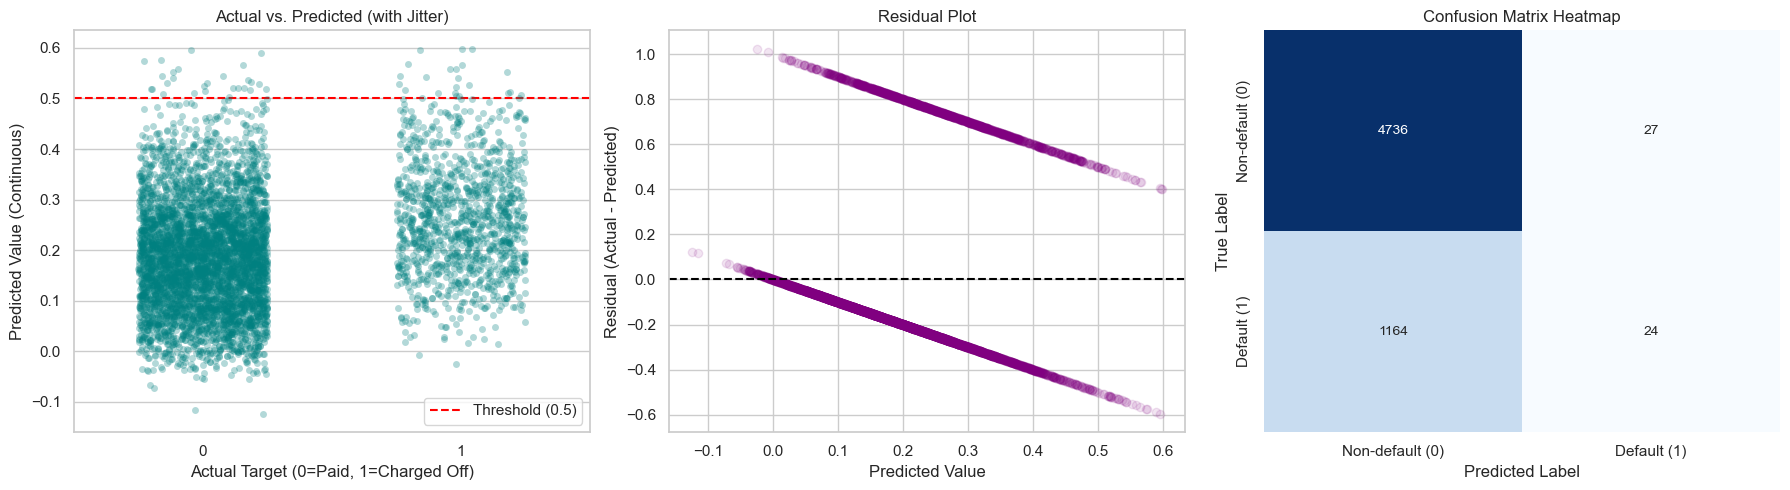

In [19]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1. Actual vs. Predicted (with Jitter)
sns.stripplot(x=y_test, y=y_pred, ax=axes[0], alpha=0.3, jitter=0.25, color='teal')
axes[0].axhline(0.5, color='red', linestyle='--', label='Threshold (0.5)')
axes[0].set_xlabel("Actual Target (0=Paid, 1=Charged Off)")
axes[0].set_ylabel("Predicted Value (Continuous)")
axes[0].set_title("Actual vs. Predicted (with Jitter)")
axes[0].legend()

# 2. Residual Plot
residuals = y_test - y_pred
axes[1].scatter(y_pred, residuals, alpha=0.1, color='purple')
axes[1].axhline(0, color='black', linestyle='--')
axes[1].set_xlabel("Predicted Value")
axes[1].set_ylabel("Residual (Actual - Predicted)")
axes[1].set_title("Residual Plot")

# 3. Confusion Matrix Heatmap
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False, ax=axes[2],
            xticklabels=['Non-default (0)', 'Default (1)'],
            yticklabels=['Non-default (0)', 'Default (1)'])
axes[2].set_xlabel("Predicted Label")
axes[2].set_ylabel("True Label")
axes[2].set_title("Confusion Matrix Heatmap")

plt.tight_layout()
plt.show()

## 12. Baseline Model Interpretation

### Baseline Model Performance
1. **Linear Regression Utility**:
   - Linear Regression fits a straight line that minimizes the sum of squared residuals. For a binary target ($0/1$), this is mathematically equivalent to a **Linear Probability Model (LPM)**.
   - Because it is unconstrained, predicted risk outputs are continuous numbers, and can sometimes lie outside the $[0, 1]$ interval. 
2. **Metric Interpretation**:
   - **MAE (~0.30) & RMSE (~0.37)**: Show that the average deviation from the actual discrete labels is substantial.
   - **$R^2$ Score (very low, typically < 10%)**: Indicates that the chosen numerical features explain very little variance in loan outcomes. This highlights that lending risk is highly complex and non-linear, or that our feature subset lacks predictive power on its own.
3. **Classification & Thresholding**:
   - Because defaults are less frequent than non-defaults (class imbalance), the regression predictions are pulled heavily towards the majority class (non-default).
   - Almost all predictions fall below the `0.5` threshold. Consequently, the model predicts the majority class (`0`) for almost all test samples. This results in **high accuracy (~80%)** but **extremely low or zero Recall**, meaning the model fails to identify actual risky borrowers who eventually default.
4. **Why Linear Regression is Inappropriate**:
   - **Heteroscedasticity**: The variance of errors is not constant; because $y$ is binary, error variance directly depends on the input feature values.
   - **Linearity Assumption**: Credit default risk has non-linear transitions (e.g., debt-to-income or FICO scores have non-linear effects on risk), which standard Linear Regression cannot capture without manual feature engineering.
   - **Lack of Probability Bounds**: Predictions outside $[0, 1]$ make risk-based pricing or standard default probabilities hard to define.
5. **Why Classification is Better Suited**:
   - In the final CrediFlux system, we will formulate this as a **binary classification problem**.
   - We will use **Logistic Regression** (which applies a sigmoid function to output bounded probabilities between 0 and 1) and **Random Forest** (which can naturally handle non-linear decision boundaries and complex feature interactions).
   - These models will allow us to adjust thresholds based on risk appetite (e.g., trading off precision and recall to minimize bank losses).